# Phase 3 / Day 3 — Backpropagation, Gradient Descent & Optimizers

## Preparing the Dataste

*Today's notebook uses the Cardiac Patient Monitoring system dataset and data preperation steps to explore Back Propagation, Gradient Descent and Optimizers.*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
df = pd.read_csv("heart_2020_cleaned.csv")
df

,HeartDisease,BMI,Smoking,AlcoholDrinking,Stroke,PhysicalHealth,MentalHealth,DiffWalking,Sex,AgeCategory,Race,Diabetic,PhysicalActivity,GenHealth,SleepTime,Asthma,KidneyDisease,SkinCancer
0,No,16.60,Yes,No,No,3.0,30.0,No,Female,55-59,White,Yes,Yes,Very good,5.0,Yes,No,Yes
1,No,20.34,No,No,Yes,0.0,0.0,No,Female,80 or older,White,No,Yes,Very good,7.0,No,No,No
2,No,26.58,Yes,No,No,20.0,30.0,No,Male,65-69,White,Yes,Yes,Fair,8.0,Yes,No,No
3,No,24.21,No,No,No,0.0,0.0,No,Female,75-79,White,No,No,Good,6.0,No,No,Yes
4,No,23.71,No,No,No,28.0,0.0,Yes,Female,40-44,White,No,Yes,Very good,8.0,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
319790,Yes,27.41,Yes,No,No,7.0,0.0,Yes,Male,60-64,Hispanic,Yes,No,Fair,6.0,Yes,No,No
319791,No,29.84,Yes,No,No,0.0,0.0,No,Male,35-39,Hispanic,No,Yes,Very good,5.0,Yes,No,No
319792,No,24.24,No,No,No,0.0,0.0,No,Female,45-49,Hispanic,No,Yes,Good,6.0,No,No,No
319793,No,32.81,No,No,No,0.0,0.0,No,Female,25-29,Hispanic,No,No,Good,12.0,No,No,No


In [3]:
#dropping duplicates
df = df.drop_duplicates().reset_index(drop=True)
df.duplicated().sum()

np.int64(0)

In [4]:
# Traget encoding
df["HeartDisease"] = df["HeartDisease"].map({"Yes":1, "No":0})

In [5]:
#seperating the target
x = df.drop(columns=["HeartDisease"])
y = df["HeartDisease"]

In [6]:
#splitting 80/20 the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size= 0.2, stratify=y, random_state=42)

In [7]:
#basic categorical features one-hot encoding
x_train = pd.get_dummies(x_train, drop_first=True)
x_test = pd.get_dummies(x_test, drop_first=True)
x_test = x_test.reindex(columns=x_train.columns, fill_value=0)

In [8]:
#numerical features scaling
numeric_to_Scale = ['BMI', 'PhysicalHealth', 'MentalHealth', 'SleepTime']
scaler = StandardScaler()
x_train[numeric_to_Scale] = scaler.fit_transform(x_train[numeric_to_Scale])
x_test[numeric_to_Scale] = scaler.transform(x_test[numeric_to_Scale])
df.shape

(301717, 18)

## The Four-step Training Loop 

*Every iteration of training a neural network repeats the same four steps in the same order mentioned below.*

**Forward Pass:** Input data flows through thr network layer by layer to produce a predicition - exactly what was performed in `Notebook6.2`.

**Compute Loss:** Prediction is compared against the true label using a loss function - Binary Cross-Entropy in this case - and a single number quantifies how wrong the prediction was.

**Backward Pass / Backpropagation:** The loss is propagated backward through the network, computing the gradient of the loss with respect to every weight and bias (e.g how much each parameter contributed to the error).

**Update Weights:** Every weight and bias is nudged slightly in the direction that reduces the loss, scaled by *learning rate: `W = W - learining_rate`* gradient.

*The cycle repeats for many epochs until the losss stops decreasing meaningfully.*




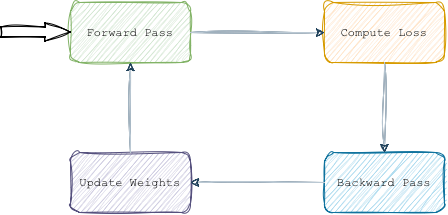

Four-step Training Loop Visualized

*The diagram was made using drawio*

## Learning Rate Experiment

In [9]:
sample_idx = np.random.RandomState(42).choice(len(x_train), size=5000, replace=False)
x = x_train.iloc[sample_idx].astype(float).values
y = y_train.iloc[sample_idx].values.reshape(-1,1)

n_features = x.shape[1]
n_hidden=8

def train_network(x,y,lr,epochs=200, seed=42):
    rng = np.random.RandomState(seed)
    w1 = rng.randn(n_features, n_hidden)*0.1
    b1 = np.zeros((1, n_hidden))
    w2 = rng.randn(n_hidden, 1)*0.1
    b2 = np.zeros((1,1))

    loss_history = []

    for epoch in range(epochs):
        #Forward pass
        z1 = x@w1 +b1
        a1 = np.maximum(0,z1) #ReLU
        z2 = a1 @ w2 + b2
        a2 = 1/(1+np.exp(-z2))#Sigmoid
    
        #Binary cross-entropy loss
        eps = 1e-8 #for numerical stability
        loss = -np.mean(y*np.log(a2+eps) + (1-y)*np.log(1 - a2+eps))
        loss_history.append(loss)
    
        #Backward pass
        dz2 = a2-y
        dw2 = a1.T@dz2/len(x)
        db2 = np.mean(dz2, axis=0, keepdims=True)
    
        da1 = dz2 @ w2.T
        dz1 = da1*(z1>0)
        dw1 = x.T@ dz1/len(x)
        db1 = np.mean(dz1, axis=0, keepdims=True)
    
        #update weights
        w1 -= lr * dw1; b1 -= lr * db1
        w2 -= lr * dw2; b2 -= lr * db2
    
    return loss_history

learning_rates = {"Too high (lr=0.5)": 5.0, "Good (lr=0.1)" :0.1, "Too low (lr=0.0001)":0.0001}

results = {name: train_network(x, y, lr) for name, lr in learning_rates.items()}

    

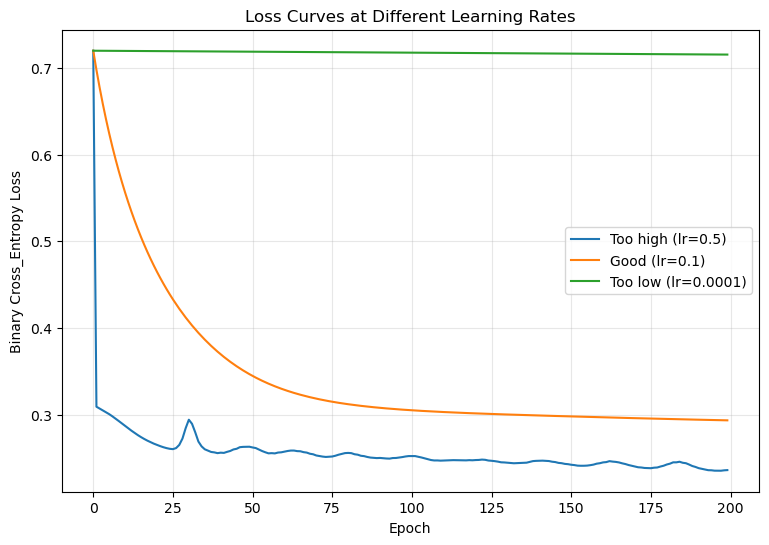

In [10]:
plt.figure(figsize=(9,6))
for name, history in results.items():
    plt.plot(history, label=name)
plt.xlabel("Epoch")
plt.ylabel("Binary Cross_Entropy Loss")
plt.title("Loss Curves at Different Learning Rates")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

| Learning Rate | Observations | Interpretation |
|---|---|---|
| 0.0001 / Too Low| The loss remains completely stable near 0.72 | The step size is insufficent to traverse the loss surface, the gradient produces small negligable udates | 
| 0.1 / Good | smooth monotonic convergance dropping sharply from 0.72 and plateauing around 0.3 | Demonstrates the ideal gradient decent optimization |
| 0.5 / Too High | Abruptly drops down to 0.31 and shows oscillations and minor spikes | The gradient stteps bounce across the loss valley values rather than cleanly descending, leading to unstable training dynamics |

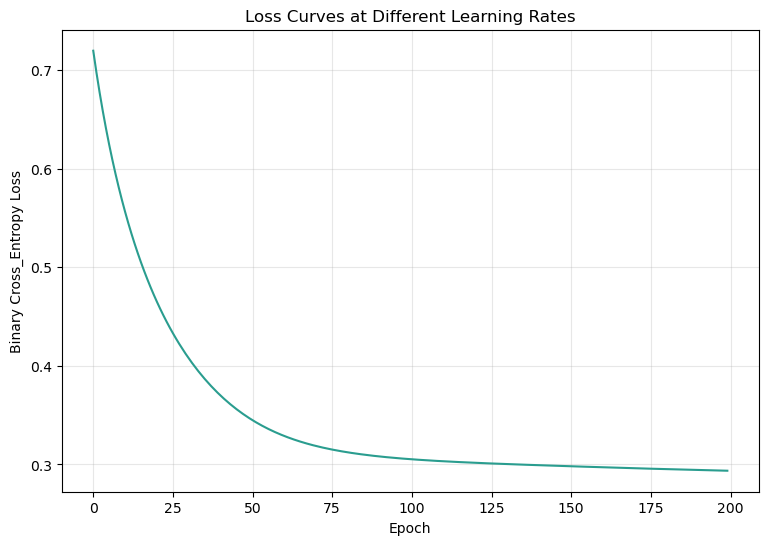

In [11]:
plt.figure(figsize=(9,6))
plt.plot(results["Good (lr=0.1)"], color="#2A9D8F")
plt.xlabel("Epoch")
plt.ylabel("Binary Cross_Entropy Loss")
plt.title("Loss Curves at Different Learning Rates")
plt.grid(alpha=0.3)
plt.show()

The **ideal Learning Rate** is `0.1`. The rapid decay of the Cross-Entropy loss from 0.72 to 0.35 indicates that the optimizer is efficiently taking large, ptoductive steps during early training. The rate of dicrease gradually slows down as the model model approaches the local mimimum on the loss surface. The transition of the curve is smooth and stable. The curve flattens out around a loss value of around 0.29 indicating that the weights have sttled near an omptimal cofigration for htis learning rate.

## Backpropagation Explaination

It computes how much each individual weight in the network contributed to the final loss. In other words, the gradient of the loss with respect to every weight and bias.

**Why is the Chain Rule essential?** a weigth on an early layer *like w1* doesn't affect the loss directly, it affects the chain of intermediate steps . `w1` affects `z`, which affects `a1`, which affests `z2`, which affects `a2` wich finally determines the loss.

This the exact chain rule from calculus which works **backward**, each layer's gradient calculation reuses the  reuses the gradient already computed for the layer just after it, rather than reconmputing the whole chain from scratch for every single weight.